# Unsupervised Learning for Macroeconomic Analysis
## PCA, Clustering & Country Grouping

**WAIFEM Machine Learning Training — 2026**

This notebook covers the unsupervised-learning toolkit for macroeconomic work:
dimensionality reduction with PCA, low-dimensional visualisation with t-SNE,
and three clustering families (K-Means, Hierarchical, DBSCAN). We finish with a
demonstration on African economies and two hands-on exercises.

The dataset is the Kaggle *Country-data* set: nine socio-economic and health
indicators for 167 countries, originally used by Help.NGO to identify
nations needing aid.


### Contents
1. Foundations of unsupervised learning
2. Curse of dimensionality (demo)
3. Data loading & exploratory analysis
4. Feature scaling & skewness handling
5. Principal Component Analysis & scree plots
6. Factor interpretation & the **Macroeconomic Resilience Index**
7. t-SNE visualisation
8. K-Means clustering
9. Hierarchical clustering & dendrograms
10. DBSCAN & anomaly detection
11. Cluster validation & cross-method comparison
12. Policy interpretation of clusters
13. **Demonstration:** African economies
14. **Hands-on exercises**


---
## 1. Foundations of Unsupervised Learning

Unlike supervised learning, **unsupervised learning has no target variable**.
The goal is to discover structure in the data:

| Family | Goal | Examples |
|---|---|---|
| Clustering | Group similar observations | K-Means, DBSCAN, Hierarchical |
| Dimensionality reduction | Compress while keeping signal | PCA, t-SNE, UMAP |
| Density estimation | Model the data distribution | KDE, GMM |
| Association | Discover co-occurrence rules | Apriori |

**Why it matters for macroeconomic work:**
- Group countries into **peer cohorts** for benchmarking
- Build composite indices (resilience, vulnerability, fragility) from many indicators
- Detect anomalies in cross-country panels
- Visualise high-dimensional surveillance data


---
## 2. The Curse of Dimensionality

In high dimensions, distance metrics become less discriminating: nearly all
pairs of points are roughly equidistant. This breaks clustering algorithms that
rely on a meaningful notion of "near" vs "far".

The demo below samples random points uniformly in [0,1]^d for increasing d, and
measures how concentrated pairwise distances become.


In [ ]:
# Imports for the whole notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score,
)
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = "{:.3f}".format


In [ ]:
# Curse-of-dimensionality demo: how does the ratio
# (max_dist - min_dist) / max_dist evolve as d grows?
rng = np.random.default_rng(RANDOM_STATE)
dims = [2, 5, 10, 25, 50, 100, 250, 500, 1000]
n_points = 500
ratios, mean_dists = [], []
for d in dims:
    X = rng.random((n_points, d))
    D = pdist(X)
    ratios.append((D.max() - D.min()) / D.max())
    mean_dists.append(D.mean())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(dims, ratios, "o-")
ax[0].set_xscale("log"); ax[0].set_xlabel("Dimensionality d")
ax[0].set_ylabel("(max - min) / max pairwise distance")
ax[0].set_title("Distance contrast collapses as d grows")

ax[1].plot(dims, mean_dists, "o-", color="darkorange")
ax[1].set_xscale("log"); ax[1].set_xlabel("Dimensionality d")
ax[1].set_ylabel("Mean pairwise distance")
ax[1].set_title("Mean distance grows but contrast shrinks")
plt.tight_layout(); plt.show()


**Takeaway.** As `d` grows the relative gap between near and far points
shrinks toward zero — every point becomes "roughly equally far". This motivates
dimensionality reduction *before* clustering when you have many correlated
indicators (which is the norm in macro panels).


---
## 3. Data Loading & Exploratory Analysis

The dataset has nine indicators per country:

| Feature | Meaning |
|---|---|
| `child_mort` | Deaths of children under 5 per 1000 births |
| `exports`, `imports` | Trade as % of GDP per capita |
| `health` | Health spending as % of GDP per capita |
| `income` | Net income per person |
| `inflation` | Annual % change in consumer prices |
| `life_expec` | Life expectancy at birth |
| `total_fer` | Average children per woman |
| `gdpp` | GDP per capita |


In [ ]:
# Load the Country-data dataset.
# We try several sources in order and use the first one that works:
#   1. kagglehub (Kaggle / Colab)
#   2. Google Drive mounted at /content/drive
#   3. Local file next to this notebook
import os

def load_country_data():
    # 1. kagglehub
    try:
        import kagglehub
        p = kagglehub.dataset_download('rohan0301/unsupervised-learning-on-country-data')
        csv = os.path.join(p, 'Country-data.csv')
        if os.path.exists(csv):
            print(f"Loaded from kagglehub: {csv}")
            return pd.read_csv(csv)
    except Exception as e:
        print(f"kagglehub unavailable ({e!r}); trying next source...")

    # 2. Google Drive (Colab)
    drive_paths = [
        '/content/drive/MyDrive/Country-data.csv',
        '/content/drive/MyDrive/Colab Notebooks/ML_WAIFEM_2026/Country-data.csv',
    ]
    for csv in drive_paths:
        if os.path.exists(csv):
            print(f"Loaded from Drive: {csv}")
            return pd.read_csv(csv)

    # 3. Local
    local_paths = [
        'Country-data.csv',
        r'G:/My Drive/Colab Notebooks/ML_WAIFEM_2026/Country-data.csv',
    ]
    for csv in local_paths:
        if os.path.exists(csv):
            print(f"Loaded from local: {csv}")
            return pd.read_csv(csv)

    raise FileNotFoundError(
        "Could not find Country-data.csv. Install kagglehub, or place "
        "the file next to this notebook."
    )

data = load_country_data()
data.head()


In [5]:
print(f"Shape: {data.shape}")
print(f"Missing values: {data.isna().sum().sum()}")
print(f"Unique countries: {data['country'].nunique()}")
data.info()


Shape: (167, 10)
Missing values: 0
Unique countries: 167
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
# Identify numeric features once
numeric_features = [c for c in data.columns if c != "country"]
print("Numeric features:", numeric_features)
data[numeric_features].describe().T


Numeric features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,count,mean,std,min,25%,50%,75%,max
child_mort,167.000,38.270,40.329,2.600,8.250,19.300,62.100,208.000
exports,167.000,41.109,27.412,0.109,23.800,35.000,51.350,200.000
health,167.000,6.816,2.747,1.810,4.920,6.320,8.600,17.900
imports,167.000,46.890,24.210,0.066,30.200,43.300,58.750,174.000
income,167.000,17144.689,19278.068,609.000,3355.000,9960.000,22800.000,125000.000
inflation,167.000,7.782,10.571,-4.210,1.810,5.390,10.750,104.000
life_expec,167.000,70.556,8.893,32.100,65.300,73.100,76.800,82.800
total_fer,167.000,2.948,1.514,1.150,1.795,2.410,3.880,7.490
gdpp,167.000,12964.156,18328.705,231.000,1330.000,4660.000,14050.000,105000.000


### 3.1 Distribution of indicators

We replace the original notebook's seven copy-pasted barplot blocks with a
single helper. Each indicator gets a 3-panel view: top 5, median 5, bottom 5.


In [7]:
def top_mid_bottom(df, feature, n=5):
    """Return three slices: top, middle, bottom n rows by `feature`."""
    sorted_df = df.sort_values(by=feature, ascending=False).reset_index(drop=True)
    mid_start = (len(sorted_df) - n) // 2
    return (
        sorted_df.iloc[:n],
        sorted_df.iloc[mid_start:mid_start + n],
        sorted_df.iloc[-n:],
    )

def plot_feature_extremes(df, feature, title=None, palette="Oranges_r"):
    top, mid, bot = top_mid_bottom(df, feature)
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    for ax, subset, label in zip(
        axes, [top, mid, bot],
        [f"Top 5 — highest {feature}",
         f"Median 5 — middle {feature}",
         f"Bottom 5 — lowest {feature}"]
    ):
        sns.barplot(x="country", y=feature, data=subset, ax=ax,
                    hue="country", palette=palette, legend=False, edgecolor="black")
        ax.set_title(label); ax.tick_params(axis="x", rotation=30)
        for rect in ax.patches:
            ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
                    f"{rect.get_height():.1f}", ha="center", fontsize=10)
    if title:
        fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()


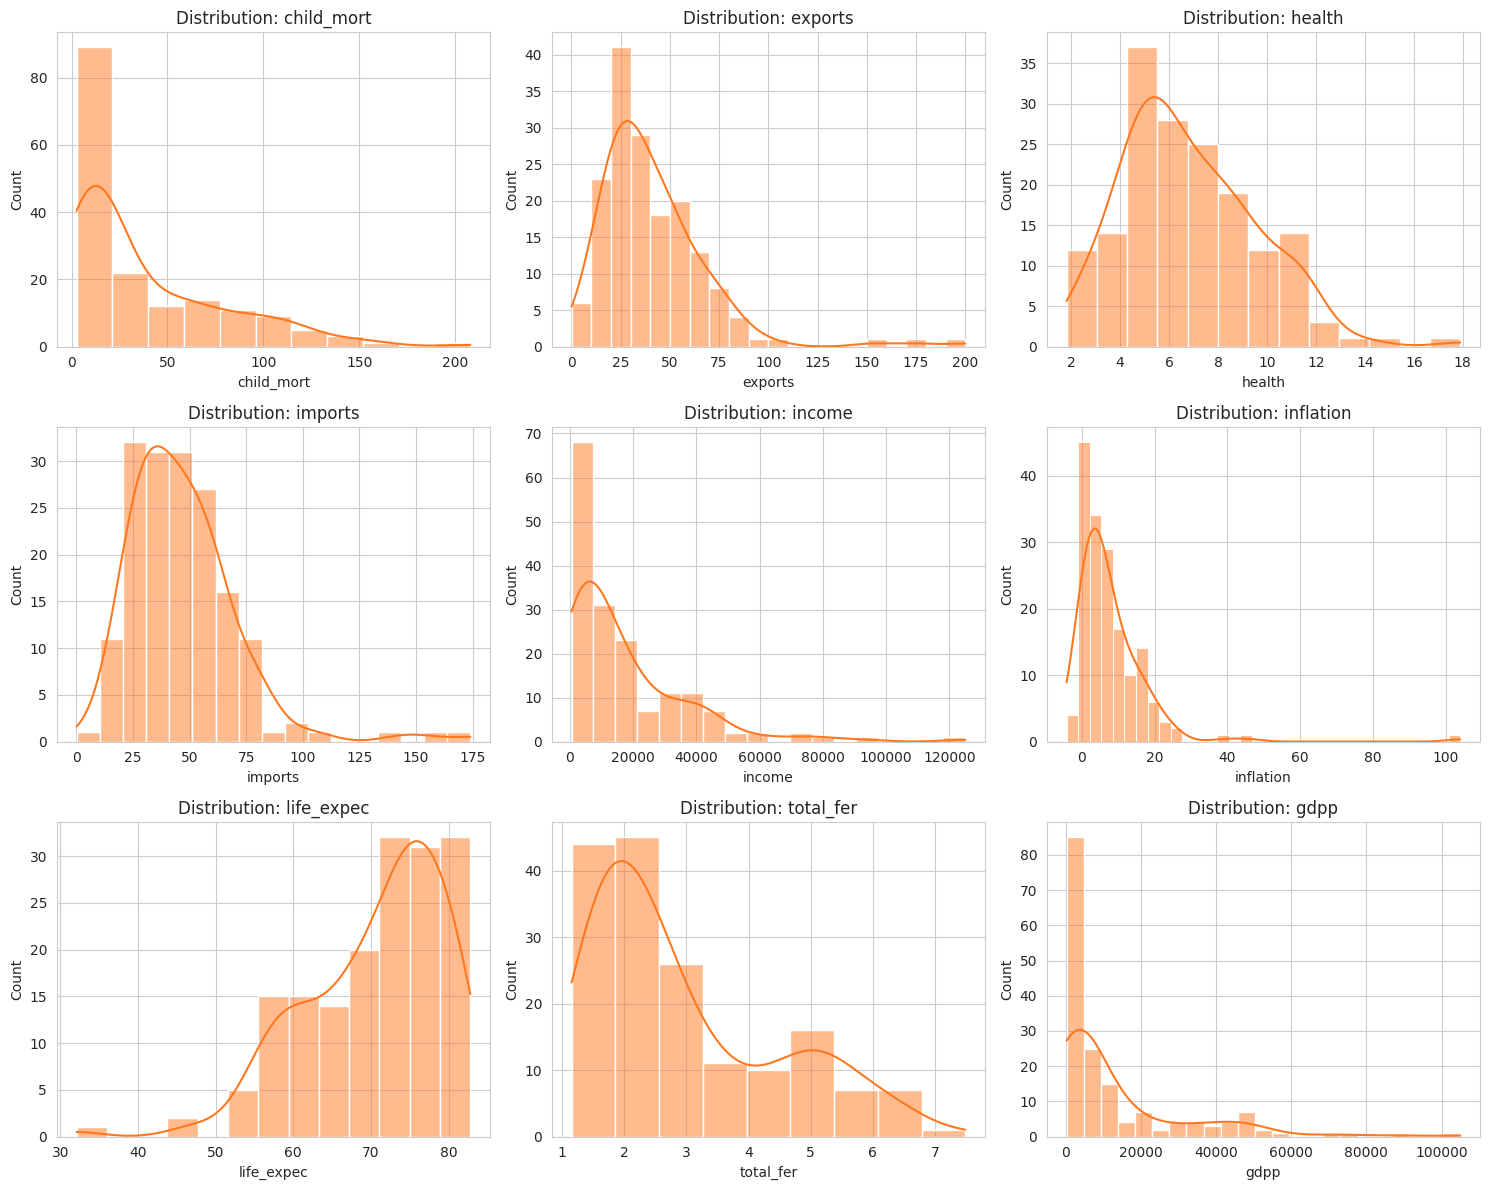

In [8]:
# Distributions of each numeric feature
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feat in zip(axes.flat, numeric_features):
    sns.histplot(data[feat], kde=True, ax=ax, color="#FF781F")
    ax.set_title(f"Distribution: {feat}")
plt.tight_layout(); plt.show()


In [9]:
# Skewness — right-skewed indicators benefit from log transformation
skew = data[numeric_features].skew().sort_values(ascending=False)
print("Skewness by feature:")
print(skew)
print("\nIndicators with |skew| > 1 (consider log transform):")
print(skew[skew.abs() > 1])


Skewness by feature:
inflation     5.154
exports       2.446
income        2.231
gdpp          2.218
imports       1.905
child_mort    1.451
total_fer     0.967
health        0.706
life_expec   -0.971
dtype: float64

Indicators with |skew| > 1 (consider log transform):
inflation    5.154
exports      2.446
income       2.231
gdpp         2.218
imports      1.905
child_mort   1.451
dtype: float64


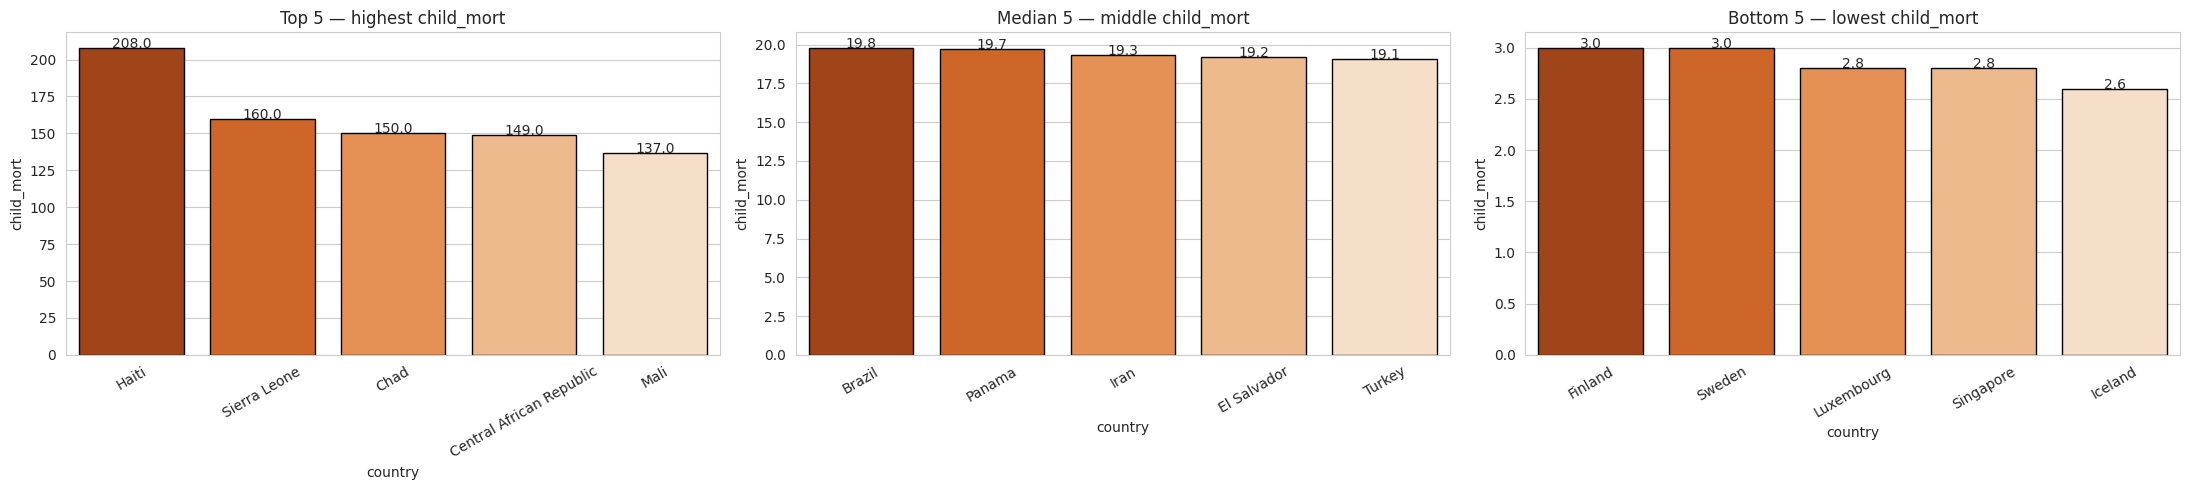

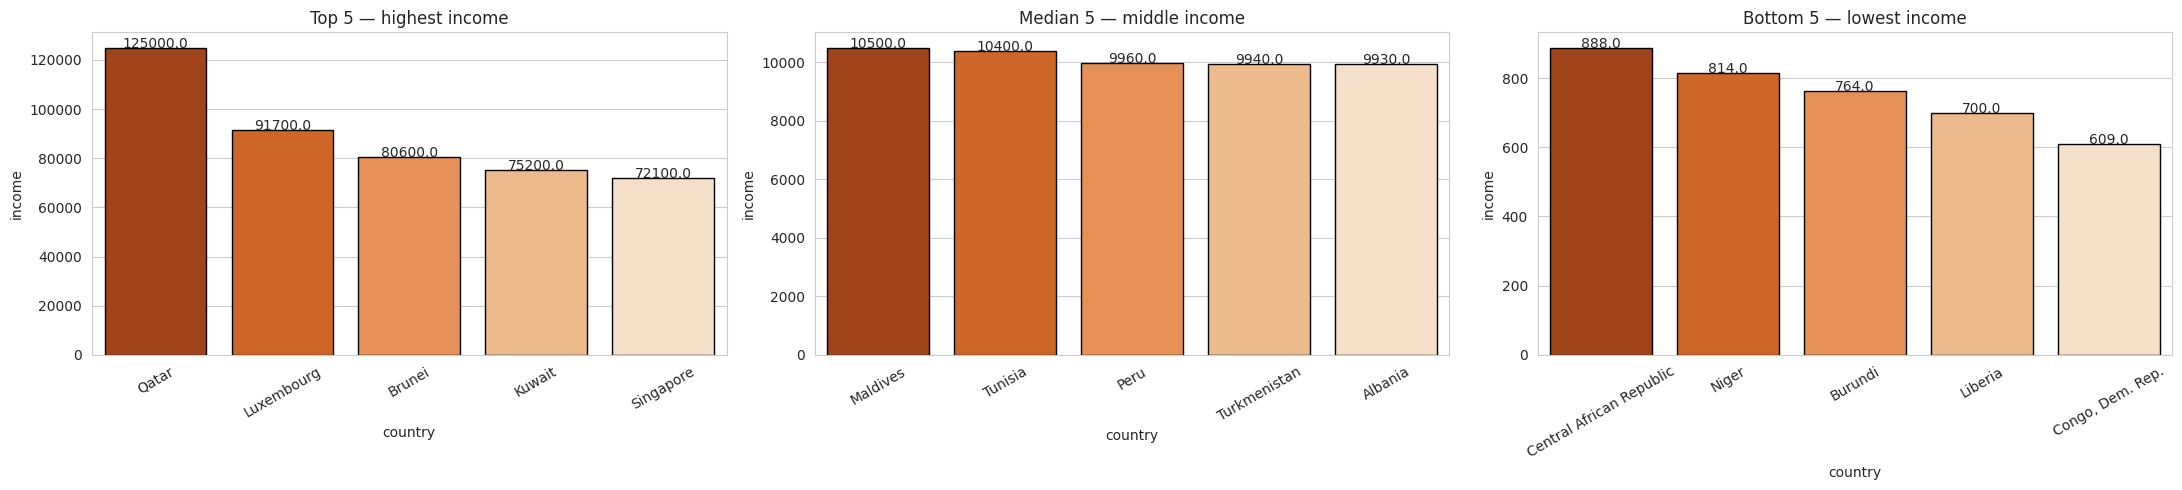

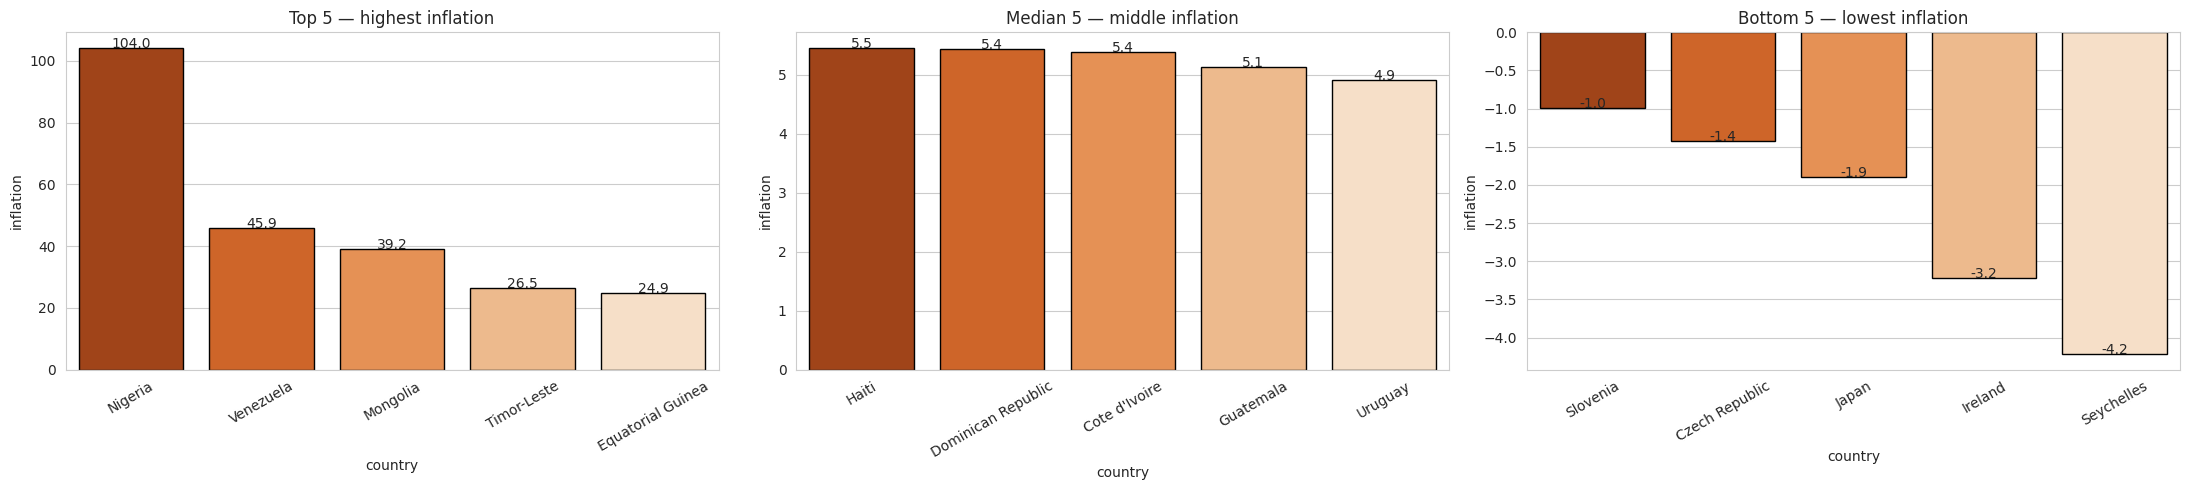

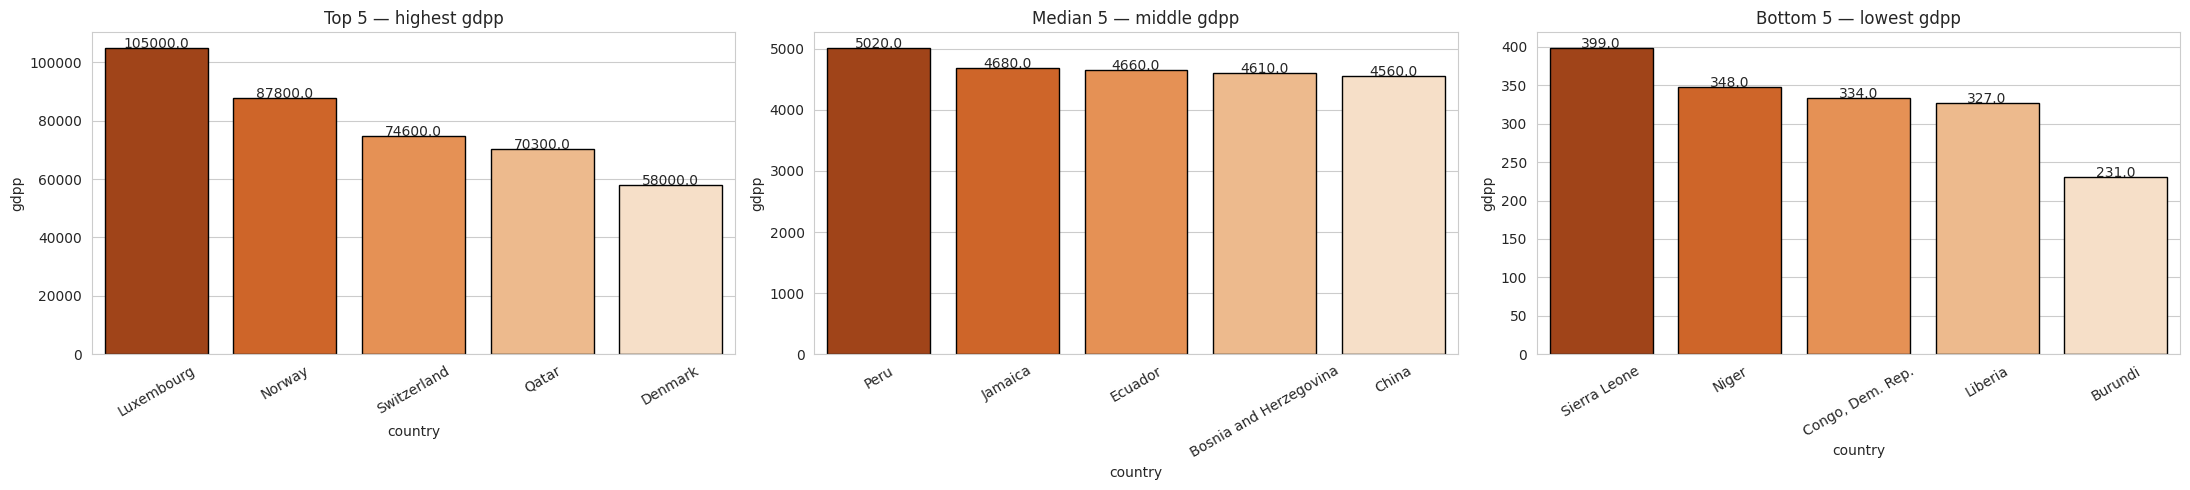

In [10]:
# Show extremes for a few key indicators
for feat in ["child_mort", "income", "inflation", "gdpp"]:
    plot_feature_extremes(data, feat)


### 3.2 Tagging African economies

We add a `region` column flagging African countries — used later for the
Africa-focused demonstration and exercises.


In [11]:
AFRICAN_COUNTRIES = {
    "Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cameroon", "Central African Republic", "Chad", "Comoros",
    "Congo, Dem. Rep.", "Congo, Rep.", "Cote d'Ivoire", "Djibouti", "Egypt",
    "Equatorial Guinea", "Eritrea", "Eswatini", "Ethiopia", "Gabon", "Gambia",
    "Ghana", "Guinea", "Guinea-Bissau", "Kenya", "Lesotho", "Liberia", "Libya",
    "Madagascar", "Malawi", "Mali", "Mauritania", "Mauritius", "Morocco",
    "Mozambique", "Namibia", "Niger", "Nigeria", "Rwanda",
    "Sao Tome and Principe", "Senegal", "Seychelles", "Sierra Leone",
    "Somalia", "South Africa", "South Sudan", "Sudan", "Swaziland",
    "Tanzania", "Togo", "Tunisia", "Uganda", "Zambia", "Zimbabwe",
}
data["region"] = np.where(data["country"].isin(AFRICAN_COUNTRIES),
                          "Africa", "Rest of world")
present_africa = sorted(set(data["country"]) & AFRICAN_COUNTRIES)
print(f"African economies present in dataset: {len(present_africa)}")
print(present_africa)


African economies present in dataset: 46
['Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 'Senegal', 'Seychelles', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia']


### 3.3 Correlation structure

Strong correlations between indicators are exactly why dimensionality reduction
is useful — much of the variance lives on a low-dimensional subspace.


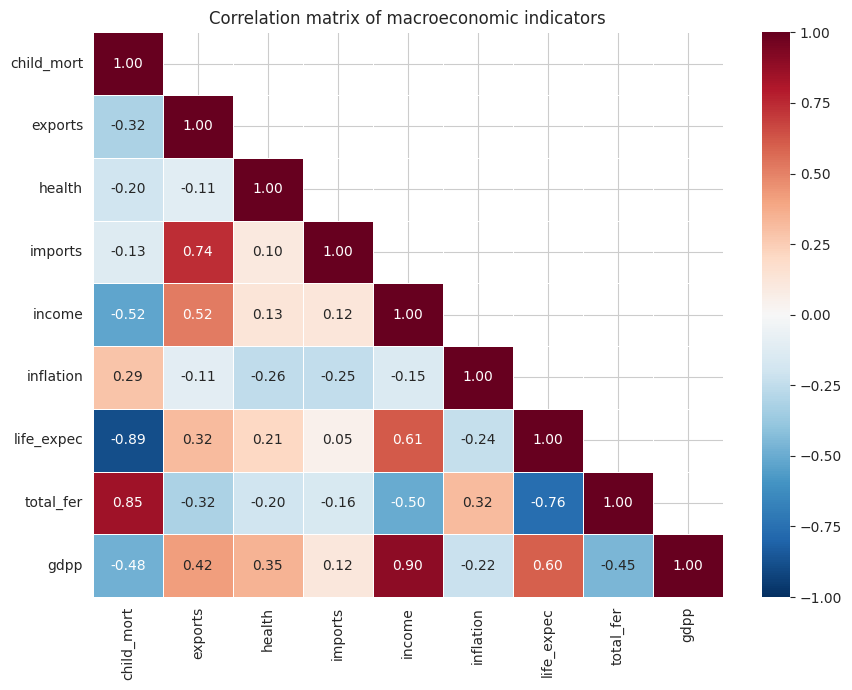

In [12]:
corr = data[numeric_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.4)
plt.title("Correlation matrix of macroeconomic indicators")
plt.tight_layout(); plt.show()


---
## 4. Feature Scaling & Skewness Handling

PCA and distance-based clustering are **scale-sensitive**. We need to:

1. Apply `log1p` to heavily right-skewed indicators (income, gdpp, child_mort).
2. Apply `StandardScaler` (zero mean, unit variance) to **all** features — not
   a mix of MinMax and Standard.

> **Note on the original notebook.** It scaled `health` with `StandardScaler`
> but everything else with `MinMaxScaler`. Mixing scales before PCA distorts
> the eigenvalues because PCA is variance-driven.


In [13]:
log_features = ["child_mort", "income", "gdpp"]
X = data[numeric_features].copy()
for f in log_features:
    X[f] = np.log1p(X[f])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),
                        columns=numeric_features, index=data.index)
X_scaled.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
child_mort,-0.000,1.003,-1.704,2.043
exports,0.000,1.003,-1.500,5.814
health,0.000,1.003,-1.828,4.047
imports,0.000,1.003,-1.940,5.266
income,0.000,1.003,-2.206,2.139
inflation,-0.000,1.003,-1.138,9.130
life_expec,0.000,1.003,-4.337,1.381
total_fer,0.000,1.003,-1.191,3.009
gdpp,-0.000,1.003,-2.043,2.048


---
## 5. Principal Component Analysis

PCA finds orthogonal directions of maximum variance in the data. The first
principal component is the linear combination of features that captures the
most variance; the second is the next-best direction orthogonal to the first;
and so on.

For a centered matrix `X`, components are eigenvectors of the covariance
matrix `X^T X / (n-1)`, and the eigenvalues are the variances along each
component.


In [14]:
pca = PCA(random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
pcs_df = pd.DataFrame(pcs, columns=[f"PC{i+1}" for i in range(pcs.shape[1])])

# Explained-variance table
ev = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_))],
    "Eigenvalue": pca.explained_variance_,
    "Explained variance ratio": pca.explained_variance_ratio_,
    "Cumulative": np.cumsum(pca.explained_variance_ratio_),
})
ev


,Component,Eigenvalue,Explained variance ratio,Cumulative
0,PC1,4.789,0.529,0.529
1,PC2,1.574,0.174,0.703
2,PC3,1.208,0.133,0.836
3,PC4,0.736,0.081,0.917
4,PC5,0.351,0.039,0.956
5,PC6,0.226,0.025,0.981
6,PC7,0.089,0.010,0.991
7,PC8,0.067,0.007,0.998
8,PC9,0.014,0.002,1.000


### 5.1 Scree plot & variance-explained curve

The **scree plot** shows eigenvalues per component (look for the "elbow"). The
**cumulative variance** curve shows how many components are needed to capture
a target share (commonly 80–90%) of total variance.


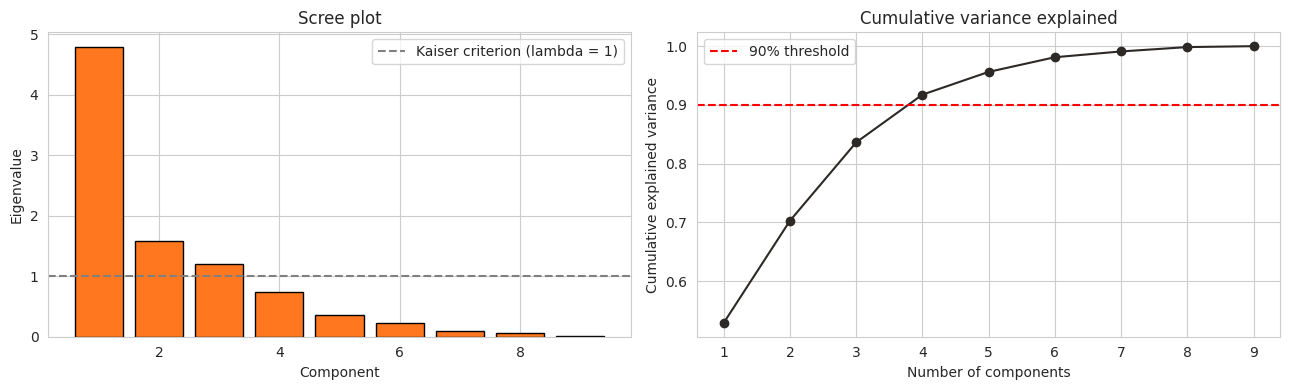

Components needed for >=90% variance: 4


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
k = np.arange(1, len(pca.explained_variance_) + 1)

# Scree plot (eigenvalues)
ax[0].bar(k, pca.explained_variance_, color="#FF781F", edgecolor="black")
ax[0].axhline(1, ls="--", color="grey", label="Kaiser criterion (lambda = 1)")
ax[0].set_xlabel("Component"); ax[0].set_ylabel("Eigenvalue")
ax[0].set_title("Scree plot"); ax[0].legend()

# Cumulative variance
ax[1].plot(k, np.cumsum(pca.explained_variance_ratio_), "o-", color="#2D2926")
ax[1].axhline(0.90, ls="--", color="red", label="90% threshold")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance")
ax[1].set_title("Cumulative variance explained"); ax[1].legend()
plt.tight_layout(); plt.show()

# Data-driven choice: smallest k reaching 90%
n_components = int(np.searchsorted(np.cumsum(pca.explained_variance_ratio_), 0.90) + 1)
print(f"Components needed for >=90% variance: {n_components}")


---
## 6. Factor Interpretation & Macroeconomic Resilience Index

PCA components are abstract linear combinations of features. They become
**economically meaningful** when we inspect the loadings (the eigenvector
weights). High |loading| of a feature on a component means that feature
contributes strongly to that component.


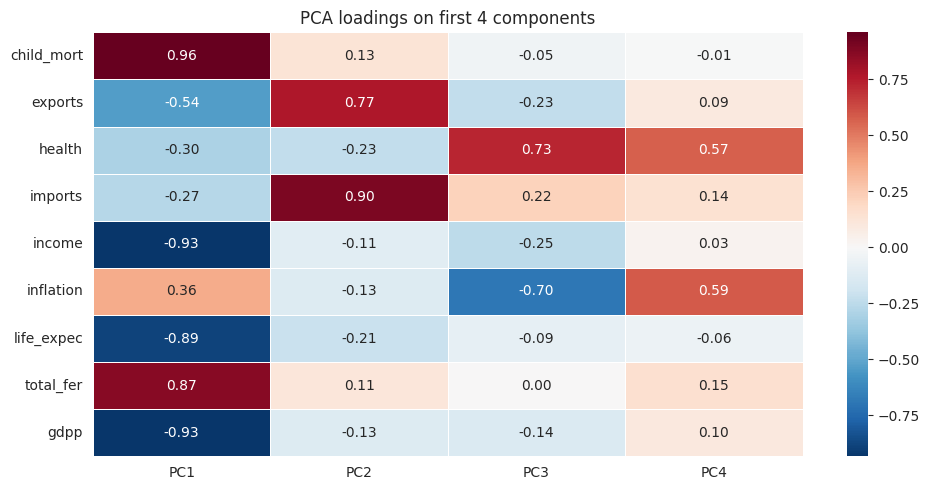

In [16]:
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),  # standardized loadings
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=numeric_features,
)
plt.figure(figsize=(10, 5))
sns.heatmap(loadings.iloc[:, :n_components], annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.4)
plt.title(f"PCA loadings on first {n_components} components")
plt.tight_layout(); plt.show()


**Reading the heatmap.** Look at each column (component) and identify the
indicators with the largest absolute loading. A typical pattern for this
dataset:

- **PC1** — separates rich/healthy economies from poor/high-mortality ones.
  Loads positively on `income`, `gdpp`, `life_expec`; negatively on
  `child_mort`, `total_fer`. This is essentially a **development axis**.
- **PC2** — captures trade openness (loadings on `exports`, `imports`).
- **PC3** — picks up the remaining variance, often inflation- or
  health-spending-driven.

We define the **Macroeconomic Resilience Index** as the (sign-corrected)
projection on PC1, scaled to 0-100 for interpretability.


In [17]:
# Macroeconomic Resilience Index (MRI)
# Sign convention: higher = more resilient (high income, high life_expec,
# low child_mort). If PC1 loads negatively on income, we flip its sign.
sign = 1 if loadings.loc["income", "PC1"] >= 0 else -1
mri_raw = sign * pcs_df["PC1"]
mri = 100 * (mri_raw - mri_raw.min()) / (mri_raw.max() - mri_raw.min())

resilience = pd.DataFrame({
    "country": data["country"],
    "region": data["region"],
    "MRI": mri,
}).sort_values("MRI", ascending=False).reset_index(drop=True)

print("Top 10 most resilient economies:")
print(resilience.head(10).to_string(index=False))
print("\nBottom 10 (least resilient):")
print(resilience.tail(10).to_string(index=False))


Top 10 most resilient economies:
    country        region     MRI
  Singapore Rest of world 100.000
 Luxembourg Rest of world  98.641
      Malta Rest of world  85.712
    Ireland Rest of world  82.919
Switzerland Rest of world  82.170
Netherlands Rest of world  80.225
    Belgium Rest of world  79.156
    Austria Rest of world  77.565
     Norway Rest of world  76.836
     Sweden Rest of world  76.433

Bottom 10 (least resilient):
                 country        region   MRI
                    Mali        Africa 8.182
            Sierra Leone        Africa 7.405
              Mozambique        Africa 6.635
                  Malawi        Africa 6.377
                 Burundi        Africa 4.206
        Congo, Dem. Rep.        Africa 2.966
                   Haiti Rest of world 2.844
                   Niger        Africa 1.616
                 Nigeria        Africa 1.137
Central African Republic        Africa 0.000


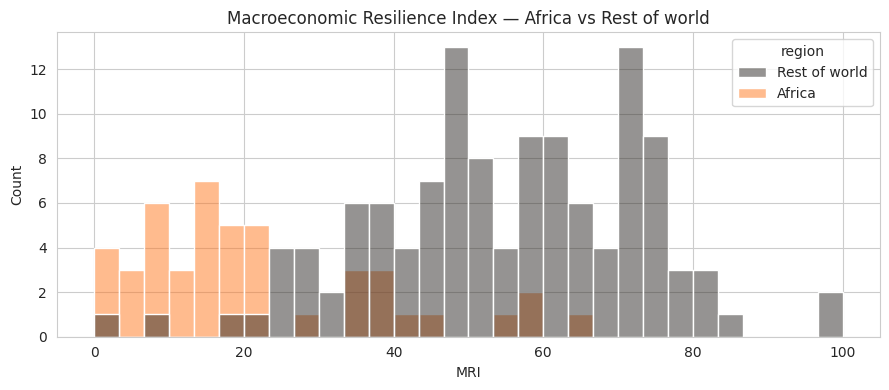

In [18]:
# Distribution of MRI by region
plt.figure(figsize=(9, 4))
sns.histplot(data=resilience, x="MRI", hue="region", bins=30,
             palette={"Africa": "#FF781F", "Rest of world": "#2D2926"})
plt.title("Macroeconomic Resilience Index — Africa vs Rest of world")
plt.tight_layout(); plt.show()


---
## 7. t-SNE Visualisation

PCA is **linear**: it captures global variance structure. t-SNE (t-distributed
Stochastic Neighbour Embedding) is a **nonlinear** technique that preserves
local neighbourhood structure — points that are close in high-dimensional
space stay close in 2D.

t-SNE is excellent for *visualisation* but **not** for downstream tasks like
clustering distances, because the global geometry is distorted.


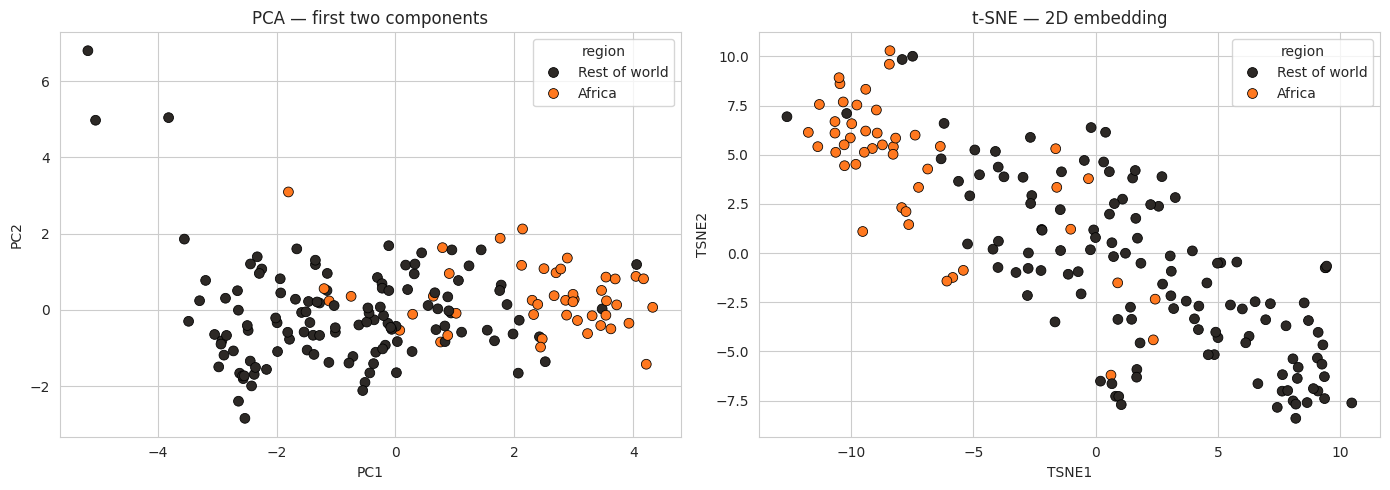

In [19]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
embed = tsne.fit_transform(X_scaled)
emb_df = pd.DataFrame(embed, columns=["TSNE1", "TSNE2"])
emb_df["country"] = data["country"]; emb_df["region"] = data["region"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# PCA 2D
sns.scatterplot(x=pcs_df["PC1"], y=pcs_df["PC2"], hue=data["region"],
                palette={"Africa": "#FF781F", "Rest of world": "#2D2926"},
                ax=axes[0], s=50, edgecolor="black")
axes[0].set_title("PCA — first two components")

# t-SNE 2D
sns.scatterplot(x=emb_df["TSNE1"], y=emb_df["TSNE2"], hue=emb_df["region"],
                palette={"Africa": "#FF781F", "Rest of world": "#2D2926"},
                ax=axes[1], s=50, edgecolor="black")
axes[1].set_title("t-SNE — 2D embedding")
plt.tight_layout(); plt.show()


---
## 8. K-Means Clustering

K-Means partitions n observations into k clusters, each represented by its
centroid (mean of its members). The algorithm alternates:

1. **Assign** each point to the nearest centroid.
2. **Update** each centroid to the mean of its members.

It minimises within-cluster sum of squares (inertia). Always set
`random_state` for reproducibility and `n_init` >= 10 to escape bad inits.


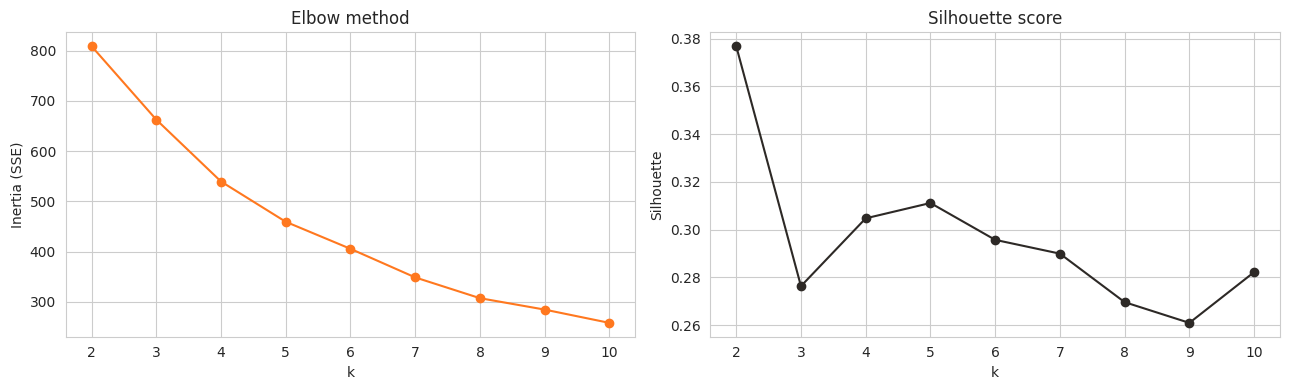

Highest silhouette at k = 2 (score = 0.377)


In [20]:
# Use the n_components PCA representation as clustering features
X_cluster = pcs_df.iloc[:, :n_components].values

# Elbow + silhouette together
sse, sil = {}, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)
    sse[k] = km.inertia_
    sil[k] = silhouette_score(X_cluster, km.labels_)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(sse.keys()), list(sse.values()), "o-", color="#FF781F")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia (SSE)")
ax[0].set_title("Elbow method")
ax[1].plot(list(sil.keys()), list(sil.values()), "o-", color="#2D2926")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
ax[1].set_title("Silhouette score")
plt.tight_layout(); plt.show()

best_k_silhouette = max(sil, key=sil.get)
print(f"Highest silhouette at k = {best_k_silhouette} (score = {sil[best_k_silhouette]:.3f})")


### 8.1 Fit final K-Means model

We use k = 3 to match the policy framing (Help Needed / Might Need Help / No
Help Needed), but the silhouette result above tells you whether 3 is genuinely
the best choice or a convention.


In [21]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)
data["kmeans_label"] = km.labels_

# === Stable cluster naming ===
# Cluster IDs are arbitrary; assign names by ranking on mean gdpp so the
# mapping is reproducible.
def name_clusters(df, label_col, by="gdpp",
                  names=("Help Needed", "Might Need Help", "No Help Needed")):
    means = df.groupby(label_col)[by].mean().sort_values()
    mapping = dict(zip(means.index, names))
    return df[label_col].map(mapping)

data["kmeans_class"] = name_clusters(data, "kmeans_label")
data["kmeans_class"].value_counts()


,count
kmeans_class,
Might Need Help,63
No Help Needed,59
Help Needed,45


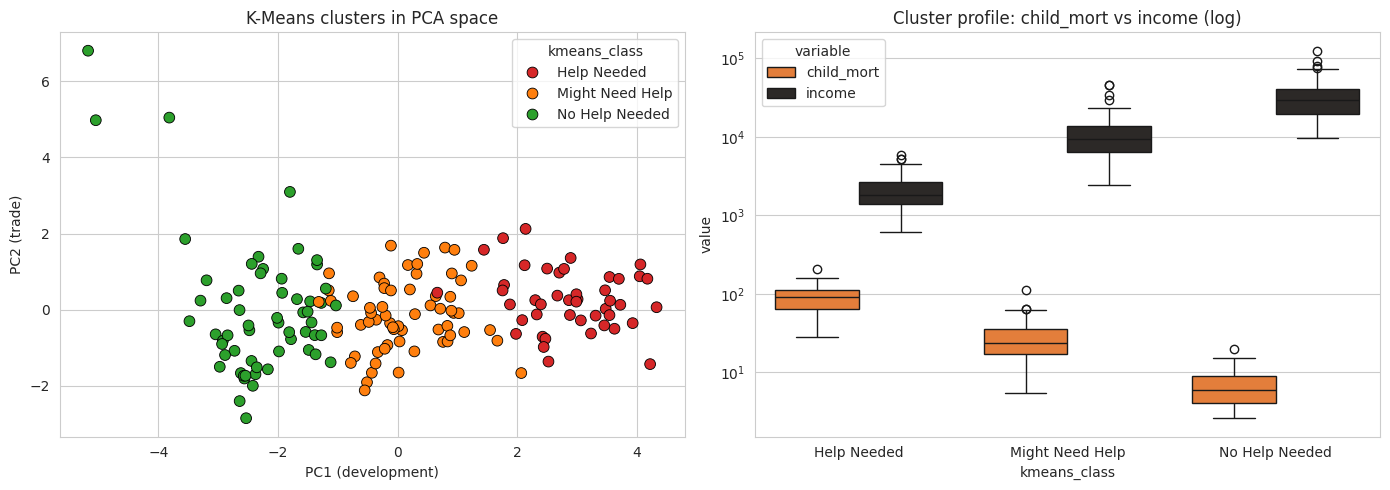

In [22]:
# Visualise clusters on PC1-PC2 with cluster centers
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
palette = {"Help Needed": "#d62728", "Might Need Help": "#ff7f0e",
           "No Help Needed": "#2ca02c"}

sns.scatterplot(x=pcs_df["PC1"], y=pcs_df["PC2"], hue=data["kmeans_class"],
                palette=palette, ax=ax[0], s=60, edgecolor="black")
ax[0].set_title("K-Means clusters in PCA space"); ax[0].set_xlabel("PC1 (development)")
ax[0].set_ylabel("PC2 (trade)")

# Boxplots: child_mort and income by cluster
melt = data.melt(id_vars="kmeans_class", value_vars=["child_mort", "income"])
sns.boxplot(data=melt, x="kmeans_class", y="value", hue="variable",
            ax=ax[1], palette=["#FF781F", "#2D2926"])
ax[1].set_yscale("log"); ax[1].set_title("Cluster profile: child_mort vs income (log)")
plt.tight_layout(); plt.show()


---
## 9. Hierarchical Clustering & Dendrograms

Hierarchical (agglomerative) clustering starts with each point in its own
cluster and merges the closest pair iteratively. The result is a tree
(dendrogram) showing the merge history; cutting the tree at a chosen height
gives a partition.

**Linkage methods** differ in how cluster-to-cluster distance is defined:

| Linkage | Distance rule | Behaviour |
|---|---|---|
| `single` | min point-to-point | Chains; sensitive to noise |
| `complete` | max point-to-point | Compact, spherical clusters |
| `average` | mean point-to-point | Compromise |
| `ward` | minimise within-cluster variance increase | Most popular default |


In [23]:
# Compare linkages by cophenetic correlation (how well does the
# dendrogram preserve pairwise distances?)
from scipy.cluster.hierarchy import cophenet
dists = pdist(X_cluster)
linkage_methods = ["single", "complete", "average", "ward"]
coph_corrs = {}
for m in linkage_methods:
    Z = linkage(X_cluster, method=m)
    c, _ = cophenet(Z, dists)
    coph_corrs[m] = c
pd.Series(coph_corrs, name="Cophenetic correlation").sort_values(ascending=False)


,Cophenetic correlation
average,0.814
complete,0.715
single,0.647
ward,0.515


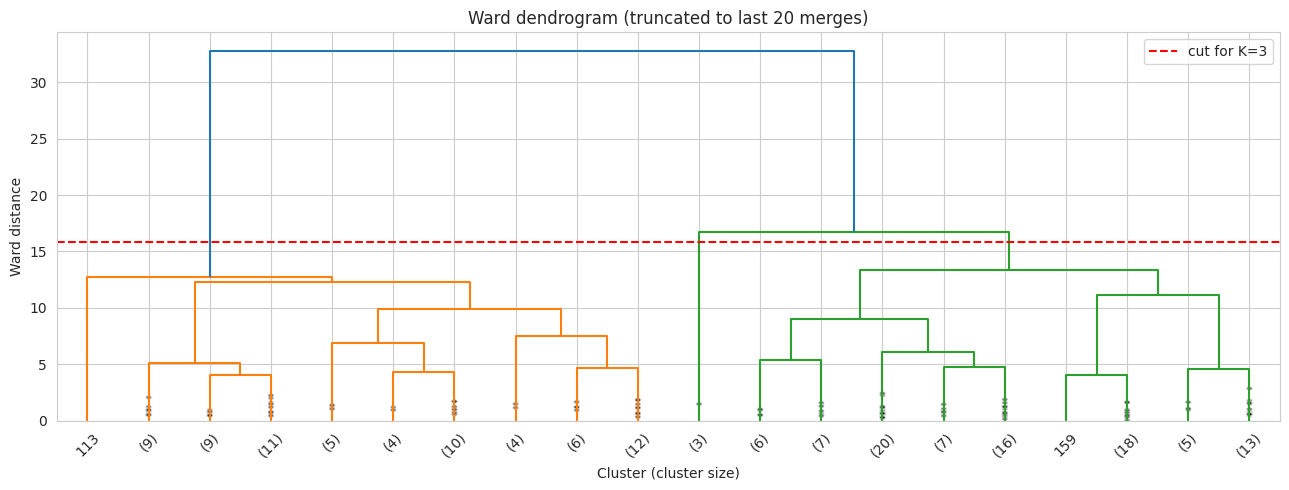

In [24]:
# Use Ward linkage; truncate for readability
Z = linkage(X_cluster, method="ward")
plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode="lastp", p=20, leaf_rotation=45,
           leaf_font_size=10, show_contracted=True)
plt.title("Ward dendrogram (truncated to last 20 merges)")
plt.xlabel("Cluster (cluster size)"); plt.ylabel("Ward distance")
plt.axhline(y=Z[-(K-1), 2] * 0.95, ls="--", color="red",
            label=f"cut for K={K}")
plt.legend(); plt.tight_layout(); plt.show()


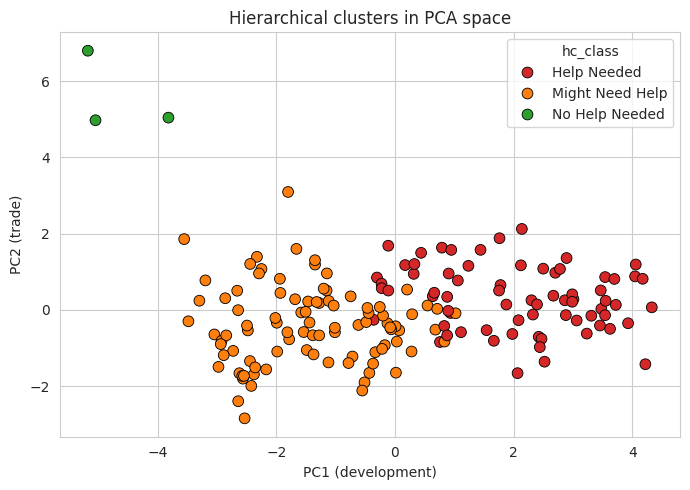

In [25]:
hc = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X_cluster)
data["hc_label"] = hc.labels_
data["hc_class"] = name_clusters(data, "hc_label")

# Visualise on PCA
plt.figure(figsize=(7, 5))
sns.scatterplot(x=pcs_df["PC1"], y=pcs_df["PC2"], hue=data["hc_class"],
                palette=palette, s=60, edgecolor="black")
plt.title("Hierarchical clusters in PCA space")
plt.xlabel("PC1 (development)"); plt.ylabel("PC2 (trade)")
plt.tight_layout(); plt.show()


---
## 10. DBSCAN

DBSCAN forms clusters from **dense neighbourhoods**. Two hyperparameters:

- `eps` — neighbourhood radius
- `min_samples` — minimum points to qualify as a core point

It naturally identifies **outliers** (label `-1`), making it useful for
flagging anomalous economies. A common rule of thumb is
`min_samples >= 2 * d` where `d` is the feature dimension.

We tune `eps` from the **k-distance graph**: sort each point's distance to its
k-th nearest neighbour and look for the "knee".


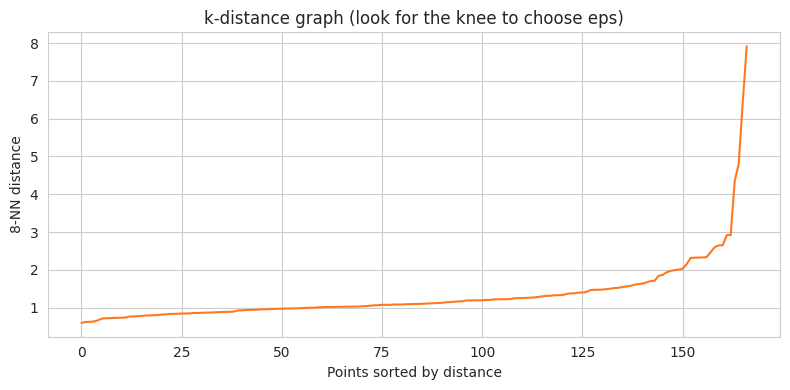

In [26]:
min_samples = 2 * n_components  # rule of thumb
knn = NearestNeighbors(n_neighbors=min_samples).fit(X_cluster)
dists, _ = knn.kneighbors(X_cluster)
k_distances = np.sort(dists[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color="#FF781F")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{min_samples}-NN distance")
plt.title("k-distance graph (look for the knee to choose eps)")
plt.grid(True); plt.tight_layout(); plt.show()


In [27]:
# Choose eps automatically using the knee (max curvature) of the sorted
# k-distance curve. If kneed is unavailable, fall back to the 90th percentile.
try:
    from kneed import KneeLocator
    kl = KneeLocator(np.arange(len(k_distances)), k_distances,
                     curve="convex", direction="increasing")
    eps = float(k_distances[kl.knee]) if kl.knee else float(np.percentile(k_distances, 90))
except ImportError:
    eps = float(np.percentile(k_distances, 90))
print(f"Chosen eps = {eps:.3f}, min_samples = {min_samples}")

db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_cluster)
data["dbscan_label"] = db.labels_
n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = int((db.labels_ == -1).sum())
print(f"DBSCAN found {n_clusters} clusters and {n_noise} outliers.")


Chosen eps = 2.014, min_samples = 8
DBSCAN found 1 clusters and 6 outliers.


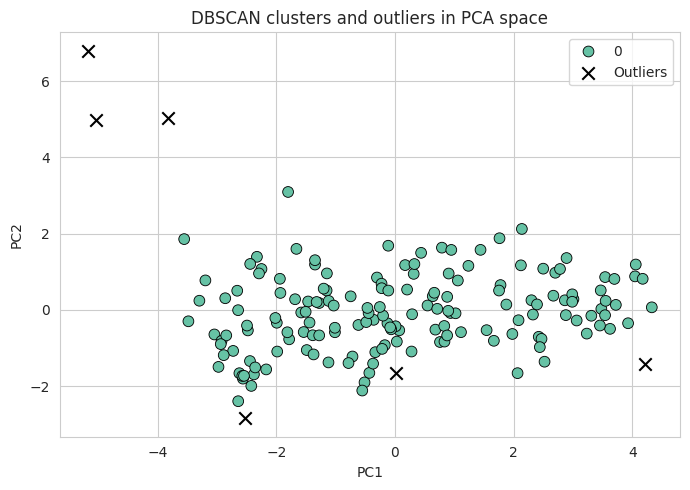

Outlier economies flagged by DBSCAN:
['Luxembourg', 'Malta', 'Nigeria', 'Singapore', 'United States', 'Venezuela']


In [29]:
# Visualise on PCA 2D
plt.figure(figsize=(7, 5))
mask = data["dbscan_label"] == -1
sns.scatterplot(x=pcs_df.loc[~mask, "PC1"], y=pcs_df.loc[~mask, "PC2"],
                hue=data.loc[~mask, "dbscan_label"], palette="Set2",
                s=60, edgecolor="black", legend="full")
plt.scatter(pcs_df.loc[mask, "PC1"], pcs_df.loc[mask, "PC2"],
            c="black", marker="x", s=80, label="Outliers")
plt.title("DBSCAN clusters and outliers in PCA space")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.tight_layout(); plt.show()

if n_noise > 0:
    print("Outlier economies flagged by DBSCAN:")
    print(data.loc[mask, "country"].tolist())


---
## 11. Cluster Validation & Cross-Method Comparison

Three internal validation metrics:

- **Silhouette** (higher = better, range [-1, 1]) — how separated clusters are.
- **Davies-Bouldin** (lower = better) — ratio of within- to between-cluster
  scatter.
- **Calinski-Harabasz** (higher = better) — variance ratio criterion.

We also use **Adjusted Rand Index** to measure agreement *between* methods.


In [30]:
def evaluate(name, labels, X):
    mask = labels != -1  # drop DBSCAN noise from metrics
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {"method": name, "silhouette": np.nan,
                "davies_bouldin": np.nan, "calinski_harabasz": np.nan,
                "n_clusters": 0, "n_noise": int((~mask).sum())}
    return {
        "method": name,
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask]),
        "n_clusters": len(set(labels[mask])),
        "n_noise": int((~mask).sum()),
    }

validation = pd.DataFrame([
    evaluate("K-Means", data["kmeans_label"].values, X_cluster),
    evaluate("Hierarchical (Ward)", data["hc_label"].values, X_cluster),
    evaluate("DBSCAN", data["dbscan_label"].values, X_cluster),
])
validation


,method,silhouette,davies_bouldin,calinski_harabasz,n_clusters,n_noise
0,K-Means,0.276,1.246,88.683,3,0
1,Hierarchical (Ward),0.365,0.847,79.104,3,0
2,DBSCAN,NaN,NaN,NaN,0,6


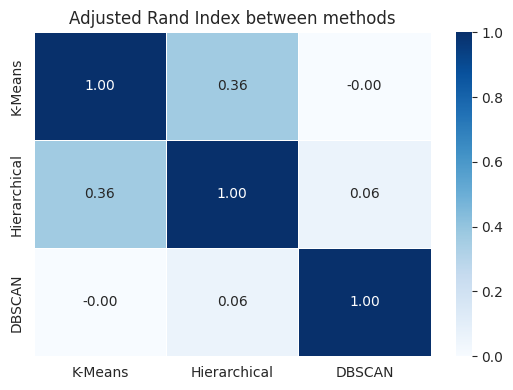

In [31]:
# Cross-method agreement: Adjusted Rand Index (1 = identical, 0 = random)
methods = {
    "K-Means": data["kmeans_label"].values,
    "Hierarchical": data["hc_label"].values,
    "DBSCAN": data["dbscan_label"].values,
}
ari = pd.DataFrame(index=methods, columns=methods, dtype=float)
for a, la in methods.items():
    for b, lb in methods.items():
        ari.loc[a, b] = adjusted_rand_score(la, lb)

plt.figure(figsize=(5.5, 4))
sns.heatmap(ari.astype(float), annot=True, fmt=".2f", cmap="Blues",
            vmin=0, vmax=1, linewidths=0.4)
plt.title("Adjusted Rand Index between methods")
plt.tight_layout(); plt.show()


---
## 12. Policy Interpretation of Clusters

A cluster is only useful when we can describe it in **policy terms**: what
makes the Help-Needed group different from the others? The cluster-profile
heatmap below shows the standardized mean of each indicator within each
K-Means cluster.


In [ ]:
profile = (
    data.groupby("kmeans_class")[numeric_features].mean()
    .reindex(["Help Needed", "Might Need Help", "No Help Needed"])
)
profile_z = (profile - data[numeric_features].mean()) / data[numeric_features].std()

plt.figure(figsize=(10, 4))
sns.heatmap(profile_z, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4)
plt.title("Cluster profile (z-scores of indicators)")
plt.tight_layout(); plt.show()

profile  # raw means


---
## 13. Demonstration: Grouping African Economies

We now restrict attention to African economies. Re-running PCA on this subset
adapts the components to **intra-African variation**, which is more
informative than projecting onto a global PCA.


In [32]:
africa = data[data["region"] == "Africa"].copy().reset_index(drop=True)
print(f"African economies: {len(africa)}")
X_africa = africa[numeric_features].copy()
for f in log_features:
    X_africa[f] = np.log1p(X_africa[f])
X_africa = pd.DataFrame(StandardScaler().fit_transform(X_africa),
                        columns=numeric_features)

pca_africa = PCA(random_state=RANDOM_STATE).fit(X_africa)
ev_africa = np.cumsum(pca_africa.explained_variance_ratio_)
k_africa = int(np.searchsorted(ev_africa, 0.90) + 1)
print(f"African PCA: {k_africa} components reach >=90% variance")
pcs_africa = pd.DataFrame(pca_africa.transform(X_africa),
                          columns=[f"PC{i+1}" for i in range(pca_africa.n_components_)])


African economies: 46
African PCA: 5 components reach >=90% variance


In [33]:
# Africa-specific Macroeconomic Resilience Index
loadings_africa = pd.DataFrame(
    pca_africa.components_.T * np.sqrt(pca_africa.explained_variance_),
    columns=[f"PC{i+1}" for i in range(pca_africa.n_components_)],
    index=numeric_features,
)
sign = 1 if loadings_africa.loc["income", "PC1"] >= 0 else -1
mri_africa = sign * pcs_africa["PC1"]
africa["MRI"] = 100 * (mri_africa - mri_africa.min()) / (mri_africa.max() - mri_africa.min())

africa_ranked = africa[["country", "MRI", "gdpp", "child_mort", "life_expec"]] \
    .sort_values("MRI", ascending=False).reset_index(drop=True)
print("African economies ranked by Macroeconomic Resilience Index:")
africa_ranked


African economies ranked by Macroeconomic Resilience Index:


,country,MRI,gdpp,child_mort,life_expec
0,Seychelles,100.000,10800,14.400,73.400
1,Libya,89.614,12100,16.600,76.100
2,Mauritius,84.246,8000,15.000,73.400
3,Tunisia,77.289,4140,17.400,76.900
4,Algeria,69.459,4460,27.300,76.500
5,Equatorial Guinea,64.006,17100,111.000,60.900
6,Morocco,61.099,2830,33.500,73.500
7,Gabon,58.282,8750,63.700,62.900
8,Egypt,56.726,2600,29.100,70.500
9,Botswana,54.611,6350,52.500,57.100


In [35]:
# K-Means on African subset (vulnerability tiers)
X_africa_cluster = pcs_africa.iloc[:, :k_africa].values
km_africa = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_africa_cluster)
africa["vulnerability_label"] = km_africa.labels_
africa["vulnerability_tier"] = name_clusters(
    africa, "vulnerability_label",
    names=("High vulnerability", "Moderate vulnerability", "Low vulnerability"),
)
africa["vulnerability_tier"].value_counts()


,count
vulnerability_tier,
High vulnerability,30
Moderate vulnerability,9
Low vulnerability,7


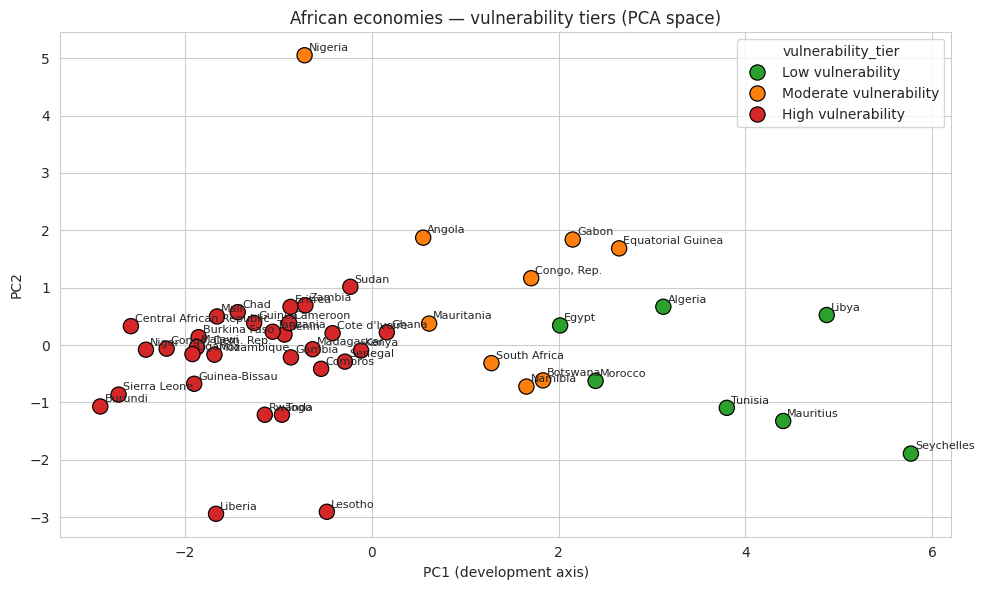

In [36]:
# Plot African economies on Africa-PCA, coloured by vulnerability tier
tier_palette = {"High vulnerability": "#d62728",
                "Moderate vulnerability": "#ff7f0e",
                "Low vulnerability": "#2ca02c"}
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x=pcs_africa["PC1"], y=pcs_africa["PC2"],
                     hue=africa["vulnerability_tier"], palette=tier_palette,
                     s=120, edgecolor="black")
for i, row in africa.iterrows():
    ax.annotate(row["country"], (pcs_africa.loc[i, "PC1"], pcs_africa.loc[i, "PC2"]),
                fontsize=8, xytext=(3, 3), textcoords="offset points")
plt.title("African economies — vulnerability tiers (PCA space)")
plt.xlabel("PC1 (development axis)"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()


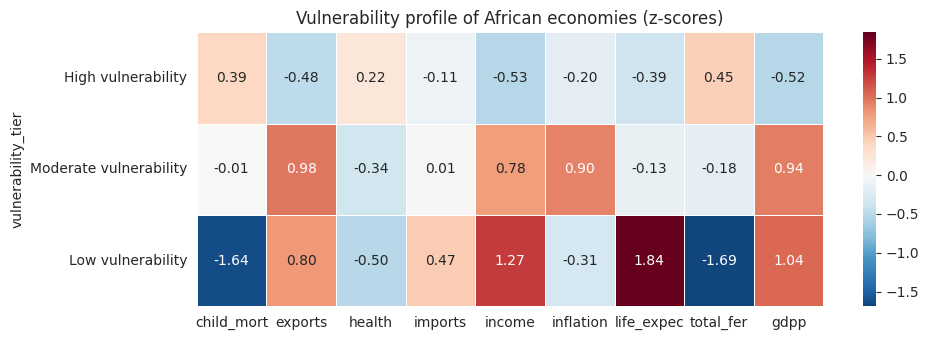

In [37]:
# Africa vulnerability profile heatmap
africa_profile = (africa.groupby("vulnerability_tier")[numeric_features].mean()
                  .reindex(["High vulnerability", "Moderate vulnerability", "Low vulnerability"]))
africa_z = (africa_profile - africa[numeric_features].mean()) / africa[numeric_features].std()
plt.figure(figsize=(10, 3.5))
sns.heatmap(africa_z, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4)
plt.title("Vulnerability profile of African economies (z-scores)")
plt.tight_layout(); plt.show()


In [38]:
# Choropleth (optional — requires plotly)
try:
    import plotly.express as px
    fig = px.choropleth(
        africa, locationmode="country names", locations="country",
        color="vulnerability_tier",
        color_discrete_map=tier_palette,
        title="African economies — vulnerability tiers",
        scope="africa",
    )
    fig.update_layout(legend_title_text="Tier")
    fig.show()
except ImportError:
    print("plotly not installed; skipping choropleth.")


---
## 14. Hands-on Exercises

Two exercises follow. Each has a clear deliverable and skeleton code marked
with `TODO`. Work in pairs and compare findings.


### Exercise 1 — Rank African economies by PCA-derived resilience

**Brief.** Section 13 built a resilience index using **PC1** only. PC1 captures
most variance but ignores secondary dimensions (trade, inflation). Build a
**weighted index** that combines the first three PCs, with weights equal to
each component's variance share.

**Deliverables:**
1. A formula for your weighted MRI.
2. A bar chart of the top-15 and bottom-15 African economies on this index.
3. A short paragraph explaining how your ranking differs from the PC1-only
   ranking and why.


In [ ]:
# === Exercise 1 — your code here ===
# Hints:
#  * weights = pca_africa.explained_variance_ratio_[:3]
#  * Decide the sign convention per PC by inspecting loadings_africa
#  * Normalize the final score to 0-100

# TODO: compute weighted_mri here
# weighted_mri = ...

# TODO: bar chart of top/bottom 15
# fig, ax = plt.subplots(...)


### Exercise 2 — Peer-group classifications for African economies

**Brief.** Build peer groups using **hierarchical clustering with Ward
linkage** on the African subset, choose `K` based on the dendrogram, and label
each cluster with a **policy-oriented name** (e.g. "Oil exporters",
"Low-income agrarian", "Diversified upper-middle-income"). Justify your labels
from the cluster profile heatmap.

**Deliverables:**
1. A truncated dendrogram with your chosen cut line drawn.
2. A profile heatmap (z-scores) per cluster.
3. A markdown table mapping each cluster to a policy label, with one-sentence
   justification.
4. A list of which African countries fall in each peer group.


In [ ]:
# === Exercise 2 — your code here ===

# Step 1: linkage matrix on X_africa_cluster
# Z_africa = linkage(X_africa_cluster, method='ward')

# Step 2: dendrogram (truncated)
# Step 3: choose K_africa from the dendrogram, fit AgglomerativeClustering
# Step 4: build profile heatmap as in Section 13
# Step 5: print countries per cluster

# TODO: implement the steps above


### Bonus — Compare with DBSCAN

DBSCAN may flag **anomalous African economies** (e.g. resource-rich Equatorial
Guinea, conflict-affected states). Repeat the DBSCAN workflow on
`X_africa_cluster` and report the outlier set.


In [ ]:
# === Bonus — your code here ===


---
## Summary & References

**What we built.**
- A uniformly-scaled PCA pipeline (log-transform skewed features, then
  standardize all) with a data-driven 90% variance cut.
- A Macroeconomic Resilience Index derived from PC1 loadings.
- Three clustering families (K-Means, Hierarchical, DBSCAN) with **stable
  cluster naming** that survives across runs.
- Cross-method validation using silhouette, Davies-Bouldin,
  Calinski-Harabasz, and Adjusted Rand Index.
- An Africa-specific drill-down with its own PCA and vulnerability tiers.

**Key methodological points for macro work.**
1. Always inspect skewness and correlations *before* PCA.
2. Standardize uniformly — never mix scalers.
3. Choose the number of components/clusters from the data (variance
   threshold, silhouette), not from convention.
4. Name clusters by ranking on a continuous indicator (`gdpp`), so labels
   are stable across runs.
5. Validate with more than one metric; compare methods via ARI.

**References.**
- Hastie, Tibshirani, Friedman, *The Elements of Statistical Learning*, ch. 14.
- Jolliffe, *Principal Component Analysis*, Springer 2002.
- Ester, Kriegel, Sander, Xu, "A density-based algorithm for discovering
  clusters", KDD 1996.
- van der Maaten, Hinton, "Visualizing data using t-SNE", JMLR 2008.
- scikit-learn documentation: `sklearn.cluster`, `sklearn.decomposition`,
  `sklearn.manifold`.
